In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/MedAssist-AI/backend/ml/datasets/new_dataset.csv")
df

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189642,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
189643,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
189644,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
189645,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df['diseases'].unique()

array(['panic disorder', 'vocal cord polyp', 'turner syndrome',
       'cryptorchidism', 'poisoning due to ethylene glycol',
       'atrophic vaginitis', 'fracture of the hand',
       'cellulitis or abscess of mouth', 'eye alignment disorder',
       'headache after lumbar puncture', 'pyloric stenosis',
       'salivary gland disorder', 'osteochondrosis', 'injury to the knee',
       'metabolic disorder', 'vaginitis', 'sick sinus syndrome',
       'tinnitus of unknown cause', 'glaucoma', 'eating disorder',
       'transient ischemic attack', 'pyelonephritis',
       'rotator cuff injury', 'chronic pain disorder',
       'problem during pregnancy', 'liver cancer', 'atelectasis',
       'injury to the hand', 'choledocholithiasis', 'injury to the hip',
       'cirrhosis', 'thoracic aortic aneurysm', 'subdural hemorrhage',
       'diabetic retinopathy', 'fibromyalgia', 'ischemia of the bowel',
       'fetal alcohol syndrome', 'peritonitis', 'injury to the abdomen',
       'acute pancreati

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(189647, 378)

In [ ]:
print(df.isnull().sum())

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64


In [ ]:
disease_counts = df["diseases"].value_counts()
disease_counts

,count
diseases,
cystitis,1219
nose disorder,1218
vulvodynia,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
kaposi sarcoma,1
open wound of the jaw,1
scurvy,1


In [ ]:
disease_counts = df["diseases"].value_counts()
disease_counts

,count
diseases,
cystitis,1219
nose disorder,1218
vulvodynia,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
kaposi sarcoma,1
open wound of the jaw,1
scurvy,1


In [ ]:
counts = df["diseases"].value_counts()

df = df[df["diseases"].isin(counts[counts >=200].index)]

In [ ]:
X = df.drop(columns=["diseases"])

y = df["diseases"]

In [ ]:
X = df.drop(columns=["diseases"])

y = df["diseases"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print(len(label_encoder.classes_))

265


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print(len(label_encoder.classes_))

265


In [ ]:
disease_counts = df["diseases"].value_counts()

print(disease_counts[disease_counts < 2])

Series([], Name: count, dtype: int64)


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(133168, 377)
(33292, 377)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=35,
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)


et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [ ]:
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=35,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
et.fit(X_train,y_train)

ExtraTreesClassifier(class_weight='balanced', max_depth=25, min_samples_leaf=2,
                     n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
col=X_train.columns

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
# ==========================
# Evaluate Individual Models
# ==========================

rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)
et_pred = et.predict(X_test)

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================
# Prediction Covariance
# ==========================

prediction_df = pd.DataFrame({
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Extra Trees": et_pred
})

rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
et_acc = accuracy_score(y_test, et_pred)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Random Forest Accuracy : {rf_acc:.4f}")
print(f"XGBoost Accuracy       : {xgb_acc:.4f}")
print(f"ExtraTrees Accuracy    : {et_acc:.4f}")

print("=" * 60)


# ==========================
# Compute Ensemble Weights
# ==========================

total_acc = rf_acc + xgb_acc + et_acc

ensemble_weights = {
    "rf": rf_acc**2,
    "xgb": xgb_acc**2,
    "et": et_acc**2
}

total = sum(ensemble_weights.values())

ensemble_weights = {
    k:v/total
    for k,v in ensemble_weights.items()
}




print("\nEnsemble Weights")
print(ensemble_weights)


# ==========================
# Soft Voting Prediction
# ==========================

rf_prob = rf.predict_proba(X_test)
xgb_prob = xgb.predict_proba(X_test)
et_prob = et.predict_proba(X_test)


# Ensure all models have same class ordering
assert (
    list(rf.classes_) ==
    list(xgb.classes_) ==
    list(et.classes_)
), "Class order mismatch between models"


final_prob = (
    ensemble_weights["rf"] * rf_prob +
    ensemble_weights["xgb"] * xgb_prob +
    ensemble_weights["et"] * et_prob
)


ensemble_pred = final_prob.argmax(axis=1)


# ==========================
# Ensemble Metrics
# ==========================

ensemble_acc = accuracy_score(
    y_test,
    ensemble_pred
)

ensemble_precision = precision_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)

ensemble_recall = recall_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_pred,
    average="weighted",
    zero_division=0
)


print("\n")
print("=" * 60)
print("SOFT VOTING ENSEMBLE")
print("=" * 60)

print(f"Accuracy  : {ensemble_acc:.4f}")
print(f"Precision : {ensemble_precision:.4f}")
print(f"Recall    : {ensemble_recall:.4f}")
print(f"F1 Score  : {ensemble_f1:.4f}")


print("\nClassification Report")
print(
    classification_report(
        y_test,
        ensemble_pred,
        target_names=label_encoder.classes_
    )
)

MODEL PERFORMANCE
Random Forest Accuracy : 0.8194
XGBoost Accuracy       : 0.8194
ExtraTrees Accuracy    : 0.7190

Ensemble Weights
{'rf': 0.3609852256515614, 'xgb': 0.36103815991729443, 'et': 0.27797661443114424}


SOFT VOTING ENSEMBLE
Accuracy  : 0.8206
Precision : 0.8270
Recall    : 0.8206
F1 Score  : 0.8222

Classification Report
                                                 precision    recall  f1-score   support

                               abdominal hernia       0.88      0.87      0.88        53
                                           acne       0.62      0.64      0.63        61
                              actinic keratosis       0.78      0.67      0.72       162
                            acute bronchiolitis       0.92      0.88      0.90       241
                               acute bronchitis       0.80      0.72      0.76       243
                             acute bronchospasm       0.55      0.69      0.61       162
                            acute kidney

In [ ]:
# ==========================
# Save Models
# ==========================
import os
import joblib
os.makedirs("../models", exist_ok=True)

joblib.dump(rf,"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/random_forest.pkl")
joblib.dump(xgb,"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/xgboost.pkl")
joblib.dump(et,"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/extra_trees.pkl")
joblib.dump(label_encoder,"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/label_encoder1.pkl")
joblib.dump(list(X_train.columns),"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/feature_columns.pkl")
joblib.dump(ensemble_weights,"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/ensemble_weights.pkl")


# Save class information
joblib.dump(list(rf.classes_),"/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/classes.pkl")


print("\nAll models saved successfully!")



All models saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/MedAssist-AI/backend/ml/datasets/new_dataset.csv")

In [ ]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
counts = df["diseases"].value_counts()

df = df[df["diseases"].isin(counts[counts >=200].index)]

In [ ]:
df.shape

(166460, 378)

In [ ]:
rf = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/random_forest.pkl")

xgb = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/xgboost.pkl")

et = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/extra_trees.pkl")

label_encoder = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/label_encoder1.pkl")

feature_columns = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/feature_columns.pkl")

ensemble_weights = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/ensemble_weights.pkl")

In [ ]:
X = df.drop(columns=["diseases"])

y = df["diseases"]

In [ ]:
#faeture importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

In [ ]:
importance.head(20)

,0
headache,0.010323
swollen lymph nodes,0.009987
neck stiffness or tightness,0.009961
hot flashes,0.009920
pus draining from ear,0.008705
cough,0.008549
dizziness,0.008412
smoking problems,0.008291
lip swelling,0.008281
vomiting,0.007984


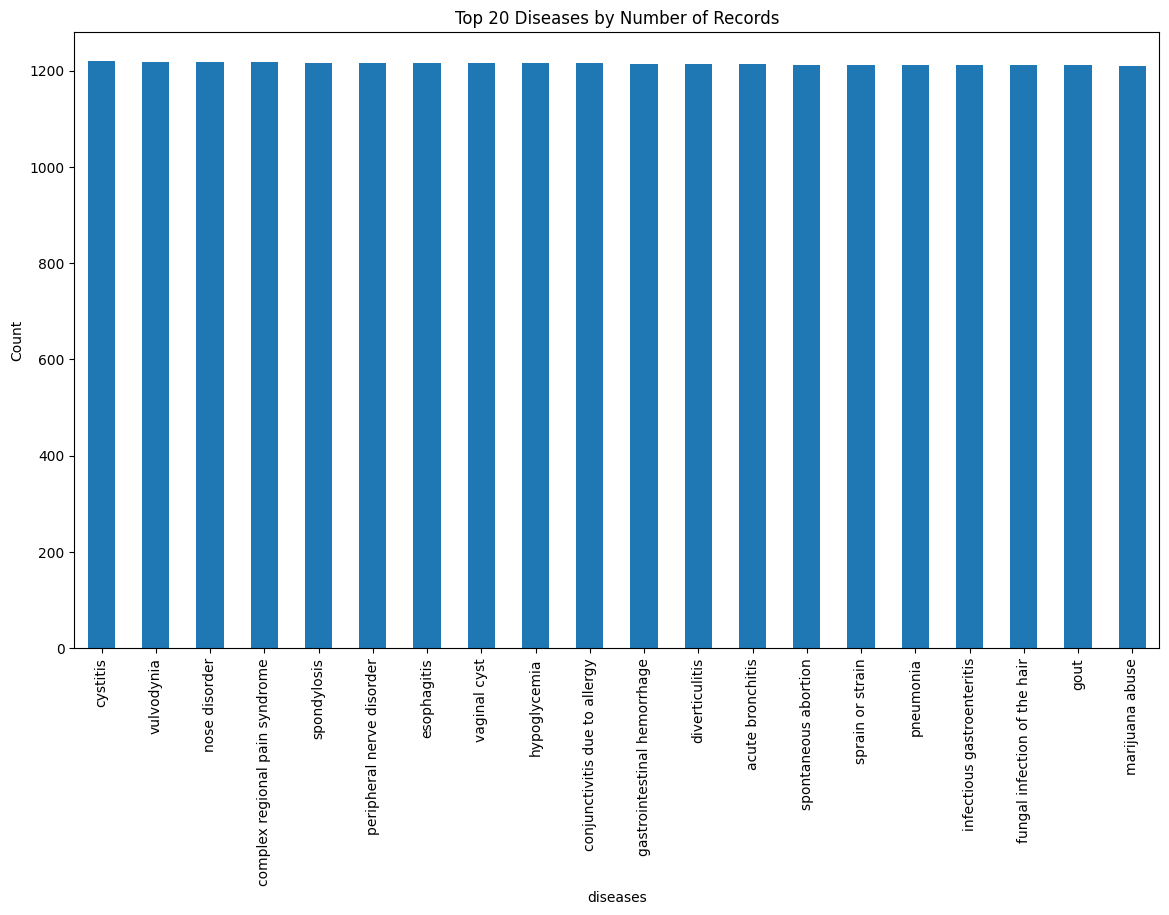

In [ ]:
plt.figure(figsize=(14,8))

df["diseases"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Diseases by Number of Records")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [ ]:
symptom_counts = X.sum().sort_values(ascending=False)

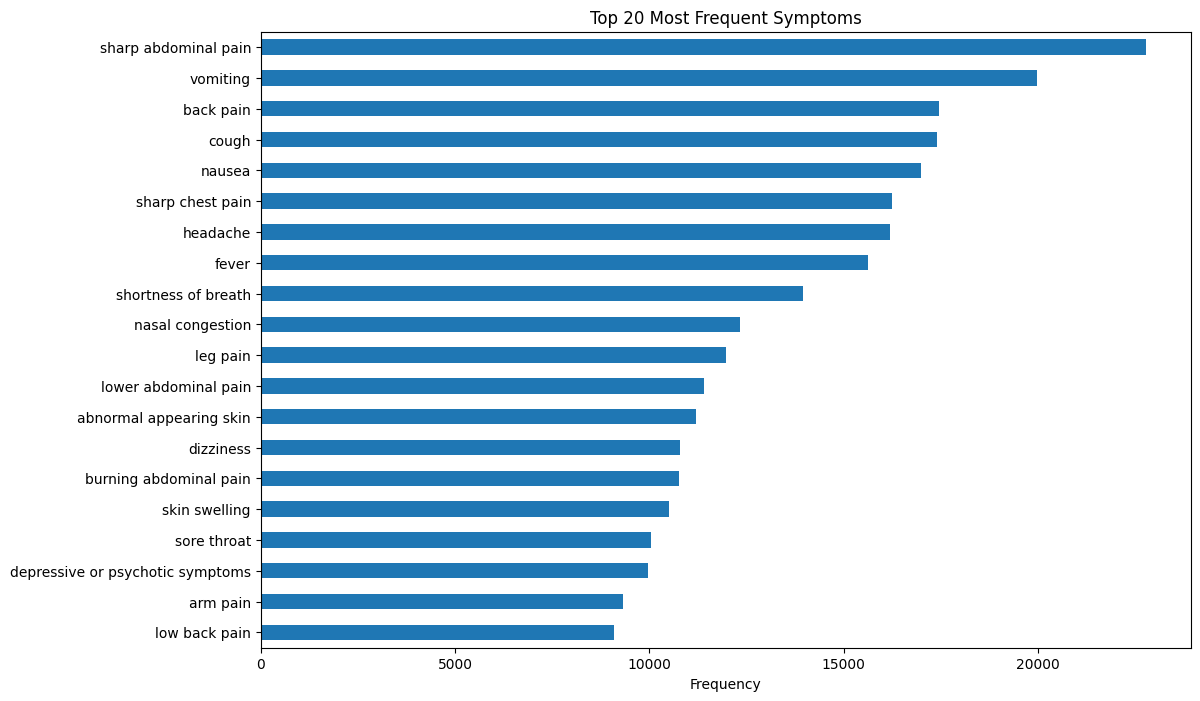

In [ ]:
plt.figure(figsize=(12,8))

symptom_counts.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Most Frequent Symptoms")

plt.xlabel("Frequency")

plt.show()

In [ ]:
y_pred = rf.predict(X)

In [ ]:
y_encoded = label_encoder.transform(y)

cm = confusion_matrix(y_encoded, y_pred)

In [ ]:
print(classification_report(y_encoded,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       265
           1       0.48      0.90      0.62       306
           2       0.90      0.73      0.80       808
           3       0.99      0.88      0.93      1204
           4       0.96      0.65      0.78      1213
           5       0.42      0.83      0.56       812
           6       0.99      0.91      0.95       808
           7       0.57      0.92      0.70       537
           8       0.71      0.92      0.80      1207
           9       0.64      0.93      0.76       300
          10       0.91      0.83      0.87       828
          11       0.84      0.91      0.87       799
          12       0.69      0.89      0.78       311
          13       0.87      0.89      0.88       313
          14       0.97      0.95      0.96       520
          15       0.97      0.89      0.93       803
          16       1.00      0.91      0.95       826
          17       0.98    

In [ ]:
probs = rf.predict_proba(X.iloc[[0]])

top3 = np.argsort(probs[0])[-3:][::-1]

for idx in top3:
    disease = label_encoder.inverse_transform([idx])[0]
    print(disease, probs[0][idx])

panic disorder 0.31955091085721926
anxiety 0.016064020154385402
heart block 0.00965268108220428


In [ ]:
def predict(symptoms):

    sample = np.zeros(len(feature_columns))

    for symptom in symptoms:
        if symptom in feature_columns:
            idx = feature_columns.index(symptom)
            sample[idx] = 1

    sample = sample.reshape(1,-1)

    rf_prob = rf.predict_proba(sample)
    xgb_prob = xgb.predict_proba(sample)
    et_prob = et.predict_proba(sample)

    probs = (
        weights['rf']*rf_prob +
        weights['xgb']*xgb_prob +
        weights['et']*et_prob
    )

    disease = label_encoder.inverse_transform([np.argmax(probs)])[0]

    return disease

In [ ]:
weights = joblib.load("/content/drive/MyDrive/MedAssist-AI/backend/ml/saved_models/ensemble_weights.pkl")

In [ ]:
predict([
    "fever",
    "cough",
    "headache"
])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


'strep throat'

In [ ]:
predict([
   "cough",
"nasal congestion",
"throat swelling"
])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


'drug reaction'

In [ ]:
for col in feature_columns[:30]:
    print(col)

anxiety and nervousness
depression
shortness of breath
depressive or psychotic symptoms
sharp chest pain
dizziness
insomnia
abnormal involuntary movements
chest tightness
palpitations
irregular heartbeat
breathing fast
hoarse voice
sore throat
difficulty speaking
cough
nasal congestion
throat swelling
diminished hearing
lump in throat
throat feels tight
difficulty in swallowing
skin swelling
retention of urine
groin mass
leg pain
hip pain
suprapubic pain
blood in stool
lack of growth


In [ ]:
prob = probs[0]

indices = np.argsort(prob)[::-1][:5]

for i in indices:
    print(
        label_encoder.inverse_transform([i])[0],
        prob[i]
    )

panic disorder 0.31955091085721926
anxiety 0.016064020154385402
heart block 0.00965268108220428
aortic valve disease 0.008975414650620808
paroxysmal supraventricular tachycardia 0.008353292428343229
